##**Business Context**

It is common now that bank's front customer support are passed through automated assistant system which maps the free-text query with an operational category before they can resolve or are assigned to the right support team member. At large scale, misrouting can become costly as it wastes both the support agent's time and questions the integrity and trust on the system.

##**Objective**

The purpose of this project is to build an intelligent intent classifier that can auto-resolve confident predictions and defer low-confidence to customer support team. This cuts handling time, raises the deflection rate and reduces the impact of errors.

###**Task**

This is a multi-class, single-label text classification for intent detection. One query maps to one of 77 intents target class.

##**Import Dependencies**

In [1]:
import random
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import math
import matplotlib.pyplot as plt
import collections
from datasets import load_dataset, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix)
from sklearn.model_selection import train_test_split
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback, set_seed)
from scipy.stats import ttest_rel


In [2]:
SEED = 37

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

##**Dataset**

The dataset is [Banking77 dataset from hugging face](https://huggingface.co/datasets/mteb/banking77) composed of online banking queries annotated with their corresponding intents. In real-world application these data from chat, ticket, and IVR logs.

In [ ]:
ds = load_dataset("mteb/banking77")

In [5]:
label_texts = sorted(list(set(ds['train']['label_text'])))
labels = sorted(list(set(ds['train']['label'])))

In [6]:
pairs = sorted(set(zip(ds["train"]["label"], ds["train"]["label_text"])))
label_names = [name for _, name in pairs]
NUM_LABELS = len(label_names)

##**Exploratory Analysis**

In [7]:
train_df = pd.DataFrame(ds['train'])

In [8]:
test_df = pd.DataFrame(ds['test'])

In [9]:
counts = train_df['label'].value_counts().sort_values()

###**Class Distribution**

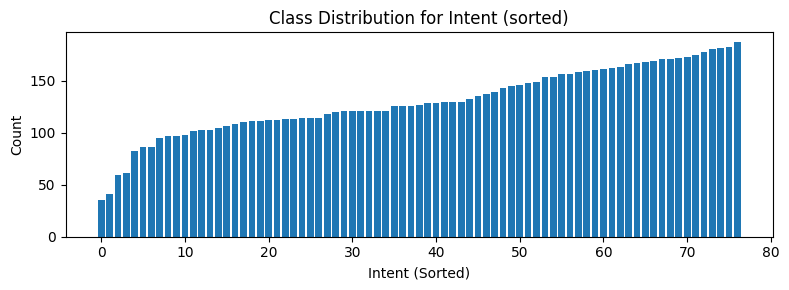

In [10]:
plt.figure(figsize=(8, 3))
plt.bar(range(len(counts)), counts.values)
plt.title('Class Distribution for Intent (sorted)')
plt.xlabel('Intent (Sorted)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


The classes are mildly imbalance, with no single dominant class. With such mild distribution, accuracy will not be inflated by a single intent. The lowest-support intents may have weaker recall, which motivates both macro-F1 as the headline metric and the class-weighted loss experiment.

###**Text Length**

In [11]:
train_df['wlen'] = train_df['text'].str.split().apply(len)

In [12]:
train_df['wlen'].describe()

,wlen
count,9993.000000
mean,11.955369
std,7.891187
min,3.000000
25%,7.000000
50%,10.000000
75%,13.000000
max,79.000000


In [13]:
train_df['wlen'].quantile(0.99)

np.float64(43.0)

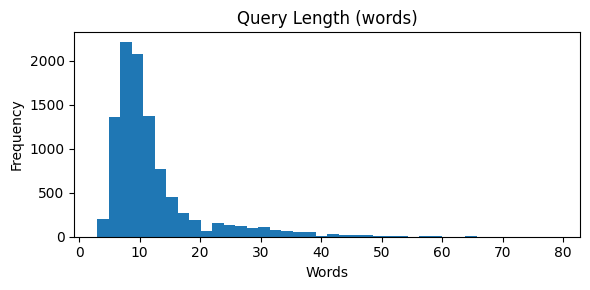

In [14]:
plt.figure(figsize=(6, 3))
plt.hist(train_df['wlen'], bins=40)
plt.title('Query Length (words)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Queries are short with a median length of 10 and the 99th percentile of 43 words. So a max length of "**64 tokens**" would effectively cover all queries without truncating meaningful content, while keeping the sequence short enough for effiecient training.

###**Duplicate**

In [15]:
train_df["text"].duplicated().sum()

np.int64(0)

In [16]:
len(set(train_df["text"]) & set(test_df["text"]))

0

No duplicate queries were found within the training set, and there was zero text overlap between the training and test splits, confirming the model is evaluated only on queries it has never seen

##**Splitting and Data Preparation**

In [17]:
tr_txt, val_txt, tr_lab, val_lab = train_test_split(train_df['text'], train_df['label'], test_size=0.10, stratify=train_df['label'], random_state=SEED)

In [18]:
tr_txt = tr_txt.tolist()
val_txt = val_txt.tolist()
tr_lab = tr_lab.tolist()
val_lab = val_lab.tolist()
te_txt = test_df['text'].tolist()
te_lab = test_df['label'].tolist()

In [19]:
print(len(tr_txt), "train /", len(val_txt), "val /", len(test_df['text']), "test")

8993 train / 1000 val / 3076 test


This dataset contains **8993** training samples, **1000** validation samples and **3076** test samples.

##**Methodology**

This project develops and compares two separate models. A TF-IDF with Logistic Regression baseline and a proposed DistilBERT model. The baseline model only understands which words appears but lacks context. This is to show how much DistilBERT gains in from context understanding.

##**Pre-Processing & Model Development**

###**Baseline Model**

In [20]:
vec = TfidfVectorizer(lowercase=True, ngram_range=(1,2), min_df=2, max_features=20000)

In [21]:
X_tr = vec.fit_transform(tr_txt)
X_val = vec.transform(val_txt)
X_te = vec.transform(te_txt)

In [ ]:
logclf = LogisticRegression(max_iter=2000, C=10, n_jobs=-1)
logclf.fit(X_tr, tr_lab)

In [23]:
b_val_pred = logclf.predict(X_val)
b_te_pred  = logclf.predict(X_te)

In [24]:
print("BASELINE Validation Accuracy: %.4f  macro-F1: %.4f" %
      (accuracy_score(val_lab, b_val_pred), f1_score(val_lab, b_val_pred, average='macro')))

BASELINE Validation Accuracy: 0.8870  macro-F1: 0.8887


In [25]:
print("BASELINE Test Accuracy: %.4f  macro-F1: %.4f  weighted-F1: %.4f" %
      (accuracy_score(te_lab, b_te_pred),
       f1_score(te_lab, b_te_pred, average='macro'),
       f1_score(te_lab, b_te_pred, average='weighted')))

BASELINE Test Accuracy: 0.8849  macro-F1: 0.8853  weighted-F1: 0.8854


The baseline model achieved macro-f1 score of 0.8853 which is close to its validation macro-f1 score of 0.8887. This confirms the task is learnable and the model can generalize without overfitting. Due to no duplicate data, the model does not have data leakage.

Balanced accuracy and macro-f1 suggests model's balanced performance despite having mild class imbalance.

###**Transformer (DistilBERT)**

In [26]:
MODEL = "distilbert-base-uncased"

In [27]:
TOK_LEN = 64

In [ ]:
tok = AutoTokenizer.from_pretrained(MODEL)

In [29]:
collator = DataCollatorWithPadding(tokenizer=tok)

In [30]:
def to_hf(texts, labels):
  d = Dataset.from_dict({"text": texts, "label": labels})
  d = d.map(lambda b: tok(b["text"], truncation=True, max_length=TOK_LEN), batched=True)
  return d

In [ ]:
tr_ds  = to_hf(tr_txt, tr_lab)
val_ds = to_hf(val_txt, val_lab)
te_ds  = to_hf(te_txt, te_lab)

In [32]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=-1)
  return {"Accuracy": accuracy_score(labels, preds),
          "Macro F1": f1_score(labels, preds, average="macro"),
          "Weighted F1": f1_score(labels, preds, average="weighted")}

In [33]:
def make_args(out, SEED):
  return TrainingArguments(
      output_dir=out,
      eval_strategy="epoch",
      save_strategy="epoch",
      load_best_model_at_end=True,
      metric_for_best_model="Macro F1",
      greater_is_better=True,
      save_total_limit=1,
      learning_rate=3e-5,
      per_device_train_batch_size=32,
      per_device_eval_batch_size=64,
      num_train_epochs=10,
      warmup_steps=int(0.1 * 10 * math.ceil(len(tr_ds) / 32)),
      weight_decay=0.01,
      logging_steps=50,
      seed=SEED,
      report_to="none")

In [ ]:
model1 = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)
trainer1 = Trainer(
    model=model1,
    args=make_args("ce", SEED),
    train_dataset=tr_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
trainer1.train()

In [35]:
print("Model-1 Validation:", trainer1.evaluate())

Training Loss,Validation Loss,Epoch,Accuracy,Macro f1,Weighted f1
0.030302,0.321613,9,0.918000,0.920578,0.917782


Model-1 Validation: {'eval_loss': 0.32161277532577515, 'eval_Accuracy': 0.918, 'eval_Macro F1': 0.920578094625942, 'eval_Weighted F1': 0.9177816531568306}


In [36]:
cnt = collections.Counter(tr_lab)
weights = torch.tensor([len(tr_lab)/(NUM_LABELS*cnt[i]) for i in range(NUM_LABELS)],
                       dtype=torch.float)

In [37]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights.to(model.device))
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
model2 = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)

In [ ]:
trainer2 = WeightedTrainer(model=model2, args=make_args("ce_weighted", SEED),
                           train_dataset=tr_ds, eval_dataset=val_ds,
                           compute_metrics=compute_metrics, data_collator=collator, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer2.train()

In [40]:
print("MODEL2 validation:", trainer2.evaluate())

Training Loss,Validation Loss,Epoch,Accuracy,Macro f1,Weighted f1
0.031761,0.279353,9,0.923000,0.924898,0.923007


MODEL2 validation: {'eval_loss': 0.2793533205986023, 'eval_Accuracy': 0.923, 'eval_Macro F1': 0.9248977964696338, 'eval_Weighted F1': 0.923006849229381}


In [41]:
comp = pd.DataFrame({
    "model": ["TF-IDF+LogReg (test)", "DistilBERT CE (val)", "DistilBERT weighted (val)"],
    "macro_f1": [f1_score(val_lab, logclf.predict(X_val), average='macro'), trainer1.evaluate()["eval_Macro F1"], trainer2.evaluate()["eval_Macro F1"]]})

Training Loss,Validation Loss,Epoch,Accuracy,Macro f1,Weighted f1
0.030302,0.321613,9,0.918000,0.920578,0.917782


Training Loss,Validation Loss,Epoch,Accuracy,Macro f1,Weighted f1
0.031761,0.279353,9,0.923000,0.924898,0.923007


In [42]:
comp

,model,macro_f1
0,TF-IDF+LogReg (test),0.888677
1,DistilBERT CE (val),0.920578
2,DistilBERT weighted (val),0.924898


Based on these results, DistilBERT Weighted has outperformed baseline model and slightly outperformed DistilBERT cross-entropy.

###**Model Robustness Test**

Both transformer models are run with six different seeds that brings randomness in initialization and weight optimization to evaluate if the model's performance is deterministic or purely by luck.

In [ ]:
SEEDS = [7, 13, 21, 37, 42, 87]

def train_and_score(weighted, seed):
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)
    TrainerClass = WeightedTrainer if weighted else Trainer
    trainer = TrainerClass(
        model=model, args=make_args(f"seed_{seed}_{'w' if weighted else 'ce'}", seed),
        train_dataset=tr_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics, data_collator=collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
    trainer.train()
    preds = np.argmax(trainer.predict(te_ds).predictions, axis=-1)
    return f1_score(te_lab, preds, average="macro")

rows = []
for seed in SEEDS:
    std = train_and_score(False, seed)
    wt  = train_and_score(True,  seed)
    rows.append({"seed": seed, "standard": std, "weighted": wt})
    print(f"seed {seed:3d} | standard {std:.4f} | weighted {wt:.4f}")

In [44]:
results = pd.DataFrame(rows)
results["difference"] = results["weighted"] - results["standard"]

In [45]:
print("\nstandard : %.4f ± %.4f" % (results["standard"].mean(), results["standard"].std()))
print("weighted : %.4f ± %.4f" % (results["weighted"].mean(), results["weighted"].std()))
print("weighted higher in %d of %d seeds" % ((results["difference"] > 0).sum(), len(SEEDS)))


standard : 0.9250 ± 0.0030
weighted : 0.9248 ± 0.0019
weighted higher in 2 of 6 seeds


In [46]:
t_stat, p_value = ttest_rel(results["weighted"], results["standard"])
print("Paired T-Test p-value: %.4f" % p_value)

Paired T-Test p-value: 0.9044


From this experiment it is clear that both DistilBERT configurations outperformed baseline model. It has also been clear that in this case weighted-class performance was statistically indistinguisable from standard cross-entropy which produced no reliable improvement which is consistent with the mild class imbalance observed during exploratory analysis.

A simpler standard cross-entropy model was selected as the final model.

In [47]:
test_out = trainer1.predict(te_ds)
test_logits = test_out.predictions
test_preds  = np.argmax(test_logits, axis=-1)

In [48]:
test_conf  = torch.softmax(torch.tensor(test_out.predictions), dim=-1).numpy().max(axis=1)

In [49]:
print("Test Evaluation:\n",
      "Accuracy %.4f\n" % accuracy_score(te_lab, test_preds),
      "Macro F1 %.4f\n" % f1_score(te_lab, test_preds, average='macro'),
      "Weighted F1 %.4f" % f1_score(te_lab, test_preds, average='weighted'))

Test Evaluation:
 Accuracy 0.9262
 Macro F1 0.9262
 Weighted F1 0.9263


The model achieved a test macro-F1 of 0.9262 (accuracy 0.9262, weighted-F1 0.9263) on the held-out test set, evaluated once. The near-identical accuracy and macro-F1 confirm balanced performance across all 77 intents despite the mild class imbalance.

In [ ]:
model1.eval()

In [51]:
demo = [
    "I lost my card, please block it",
    "How do I top up my account?",
    "What is the daily withdrawal limit?",
    "My payment was declined at a shop",
    "When will my new card get here?",
    "Can I swap one currency for another?",
    "I can't see my PIN anywhere",
    "My card isn't working at the ATM",
]

In [52]:
for q in demo:
  enc = tok(q, return_tensors="pt", truncation=True, max_length=64).to(model1.device)
  with torch.no_grad():
      probs = F.softmax(model1(**enc).logits, dim=-1)[0]
  conf, idx = probs.max().item(), probs.argmax().item()
  print(f'"{q}"\n Intent: {label_names[idx]}  (confidence {conf:.2f})\n')

"I lost my card, please block it"
 Intent: pin_blocked  (confidence 0.46)

"How do I top up my account?"
 Intent: topping_up_by_card  (confidence 0.82)

"What is the daily withdrawal limit?"
 Intent: atm_support  (confidence 0.33)

"My payment was declined at a shop"
 Intent: declined_card_payment  (confidence 0.98)

"When will my new card get here?"
 Intent: card_arrival  (confidence 0.87)

"Can I swap one currency for another?"
 Intent: exchange_via_app  (confidence 0.88)

"I can't see my PIN anywhere"
 Intent: get_physical_card  (confidence 0.99)

"My card isn't working at the ATM"
 Intent: declined_cash_withdrawal  (confidence 0.96)



To demonstrate the model's outcome it was tested on 8 constructed queries. Each Query is predicted with an intent and the model's confidence on its prediction. For queries which has marked low confidence can be redirected to a human agent to get resolved.

##**Error Analysis**

In [53]:
cm = confusion_matrix(te_lab, test_preds, labels=list(range(NUM_LABELS)))

###**Top Confused Intent Pairs**

In [54]:
pairs = []
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], label_names[i], label_names[j]))
pairs.sort(reverse=True)

In [55]:
print("Top confused pairs (True and Predicted):")
for n, t, p in pairs[:10]:
    print(f"  {n:3d} Queries | True: {t} | Predicted: {p}")

Top confused pairs (True and Predicted):
    7 Queries | True: why_verify_identity | Predicted: verify_my_identity
    4 Queries | True: verify_my_identity | Predicted: why_verify_identity
    4 Queries | True: pending_transfer | Predicted: balance_not_updated_after_bank_transfer
    4 Queries | True: declined_transfer | Predicted: declined_card_payment
    4 Queries | True: card_arrival | Predicted: card_delivery_estimate
    3 Queries | True: wrong_amount_of_cash_received | Predicted: declined_cash_withdrawal
    3 Queries | True: transfer_timing | Predicted: balance_not_updated_after_bank_transfer
    3 Queries | True: top_up_reverted | Predicted: top_up_failed
    3 Queries | True: top_up_by_bank_transfer_charge | Predicted: transfer_fee_charged
    3 Queries | True: pin_blocked | Predicted: change_pin


From these results, it is clear that top confused pairs are symantically adjacent. The most confused pairs goes both directions indicating the two intents themselves overlap rather than a one-sided model weakness.

###**Confidently Wrong Analysis**

In [56]:
probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
conf  = probs.max(axis=1)
wrong = test_preds != np.array(te_lab)

In [57]:
THRESH = 0.90
hi_conf_wrong = wrong & (conf >= THRESH)
lo_conf_wrong = wrong & (conf <  THRESH)

In [58]:
print(f"Total errors: {wrong.sum()}")
print(f"  High-confidence (>= {THRESH}) errors [DANGEROUS, auto-acted]: {hi_conf_wrong.sum()} "
      f"({100*hi_conf_wrong.sum()/max(wrong.sum(),1):.1f}% of errors)")
print(f"  Low-confidence errors [safely deferrable to human]: {lo_conf_wrong.sum()}")

Total errors: 227
  High-confidence (>= 0.9) errors [DANGEROUS, auto-acted]: 61 (26.9% of errors)
  Low-confidence errors [safely deferrable to human]: 166


In [59]:
idx = np.where(hi_conf_wrong)[0][:5]
for k in idx:
    print(f"\n  text: {te_txt[k]}")
    print(f"  true: {label_names[te_lab[k]]}  | predicted: {label_names[test_preds[k]]}"
          f"  | conf: {conf[k]:.2f}")


  text: When will I get my card?
  true: card_arrival  | predicted: card_delivery_estimate  | conf: 0.95

  text: How do I know when my card will arrive?
  true: card_arrival  | predicted: card_delivery_estimate  | conf: 0.97

  text: Where did this fee come from?
  true: extra_charge_on_statement  | predicted: card_payment_fee_charged  | conf: 0.96

  text: Am I able to exchange currencies?
  true: fiat_currency_support  | predicted: exchange_via_app  | conf: 0.99

  text: Can I exchange currencies?
  true: fiat_currency_support  | predicted: exchange_via_app  | conf: 0.95


In [60]:
print("max confidence overall:", probs.max(), "| mean top-prob:", probs.max(axis=1).mean())

max confidence overall: 0.9949432 | mean top-prob: 0.93903106


The Confidently Wrong analysis reveals that ~27% of the errors (227) have high confidence (+90%). To add to it, the mean confidence on error is ~94%, indicating that the model is highly confident even in errors. This determines that the confident alone is a weak indicator of correctness. The result also suggests that the model is the most confident on ambiguous intents ("card_arrival" vs "card_delivery_estimate").

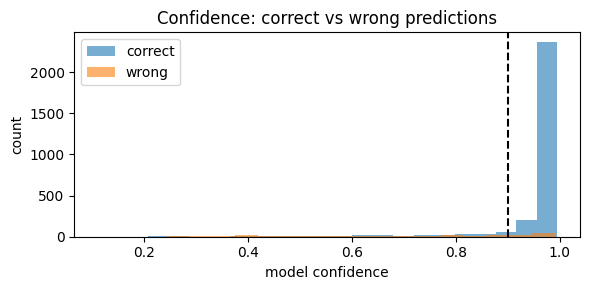

In [61]:
plt.figure(figsize=(6,3))
plt.hist(conf[~wrong], bins=20, alpha=0.6, label="correct")
plt.hist(conf[wrong],  bins=20, alpha=0.6, label="wrong")
plt.axvline(THRESH, color="k", linestyle="--")
plt.xlabel("model confidence"); plt.ylabel("count"); plt.legend()
plt.title("Confidence: correct vs wrong predictions")
plt.tight_layout(); plt.show()


This diagram visualizes the claim that the model in itself is highly confident model, verifying previous claims.

##**Confidence Based Routing**

27% of errors occurs at high confidence. This section tests whether a confidence threshold can be used to route queries and what threshold would the system provide high-automation and minimal risk with balanced human-agent work load.

In [62]:
te = np.array(te_lab)
wrong = test_preds != te

In [63]:
print(f"{'Thres.':} | {'Auto Routed %':>13} | {'Errors among auto-routed':>22} | {'deferred %':>10}")
for t in [0.80, 0.90, 0.95, 0.99]:
    auto = test_conf >= t
    if auto.sum() == 0:
        continue
    err_in_auto = (wrong & auto).sum() / auto.sum() * 100
    print(f"{t:>6.2f} | {100*auto.mean():>13.1f} | {err_in_auto:>24.1f} | {100*(~auto).mean():>10.1f}")

Thres. | Auto Routed % | Errors among auto-routed | deferred %
  0.80 |          91.0 |                      3.5 |        9.0
  0.90 |          86.4 |                      2.3 |       13.6
  0.95 |          80.3 |                      1.6 |       19.7
  0.99 |          27.8 |                      0.2 |       72.2


From the table above our sweet-spot for threshold would be 95% confidence, it automates 80% of the queries among which only 1.6% were error while also balancing the human-agent workload by having ~20% query redirected to them compared to ~72%(aggressive) and ~14% (mild), which places the 95% threshold at a balanced trade-off spot.

##**Final Discussion**

###**Strengths**

1.   A standard model development pipeline was followed with stratified validation split and test set was evaluated only once to prevent leakage.
2.   A baseline model was built for measuring the task's performance over Transformer model.
3.   The project uses a real dataset of customer banking queries and adresses a genuine business problem, making this a highly relevant and of significant impact in customer service.
4.   The model was evaluated beyond just accuracy, using macro-F1 to account for 77 imbalanced classes.
5.   The model was rigorously tested across six random seeds rather than relying on a single run.
6. A confidence-error analysis was performed to check the reliability of the prediction the model makes for deployment strategy.




###**Limitations**

1. The model is confident by default. 27% of its errors are made with +90% confidence. Confidence filtering is not a good metric to distinguish errors and correct classification.
2. The most frequent errors were found to be ambiguous labels which even for a human-evaluator would be confusing.
3. A robust label schema is missing to handle the ambiguity for some label to reduce the error.

###**Business Implications**

1. The model offers a strong but imperfect basis for automating customer support with high-confidence predictions of approximately 80% can be automated at a 0.95 confidence threshold with only 1.6% of error.
2. Redirecting low-confident predictions to human support team member can enhance the customer experience by avoiding any mistaken automation.
3. There is still a chace of high-impact errors being automated wrongfully, these needs to be taken into account and made appropriate optimzation of data collection and mapping as given in recommendation.

###**Recommendations**

1. The model can be deployed with confidence-based routing, with confidence gated at 95% giving high automation, low risk and balanced delegation of the query.
2. Confidence alone is not reliable for correctness, treat it as signal rather than guarantee of correctness.
3. Review and merge the most confused intent pairs which are similar in nature or propose a multi-label schema for example "business impact" mapping.
4. Prefer a simple standard model over class-weighting to reduce complexity.